# 2 流场与驻点可视化

本 Notebook 对应项目二任务 2.1 与 2.3，目标是：

1. 可视化不同环量下的流线与等势线。
2. 对比驻点位置随 $\Gamma$ 的迁移。
3. 观察接近临界环量 $4\pi Ua$ 时的流场特征。

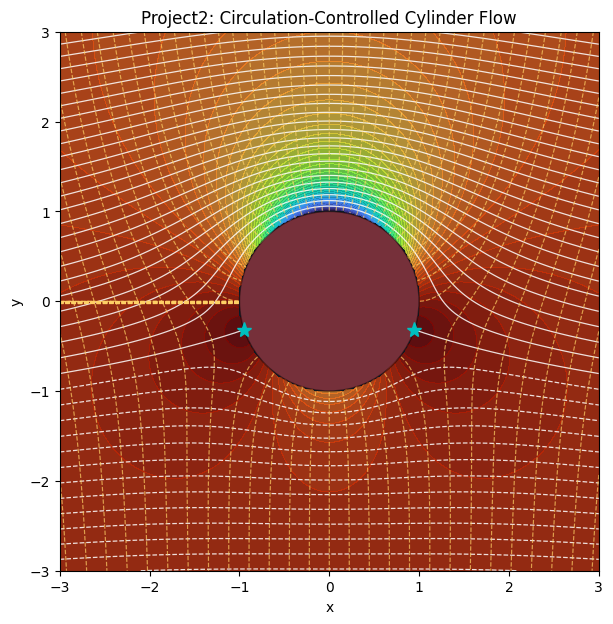

saved: /Users/fancy2/work/code/fubianhanshu/flow_project2/reports/figures/stage2_flow_snapshot.png


array([ 0.94798672-0.31830989j, -0.94798672-0.31830989j])

In [4]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'src').exists():
    for p in [root, *root.parents]:
        if (p / 'src').exists() and (p / 'requirements.txt').exists():
            root = p
            break
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.ui.simulator import FlowSimulator
from src.visualization.plot_flow import plot_stream_and_potential

U = 1.0
a = 1.0
gamma = 4.0

sim = FlowSimulator(U=U, a=a, gamma=gamma, n=221)
out = sim.run()
fig, ax = plot_stream_and_potential(
    out['X'], out['Y'], out['phi'], out['psi'],
    a=a, cp=out['cp'], stagnation=out['stagnation'],
    show_pressure=True, show_potential=True
)

fig_dir = root / 'reports' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
flow_fig_path = fig_dir / 'stage2_flow_snapshot.png'
fig.savefig(flow_fig_path, dpi=180, bbox_inches='tight')

plt.show()
print('saved:', flow_fig_path)
out['stagnation']

## 驻点迁移扫描

根据

$$
\sin\theta_s = -\frac{\Gamma}{4\pi Ua}
$$

当 $|\Gamma| > 4\pi Ua$ 时，表面驻点消失。下面做参数扫描。

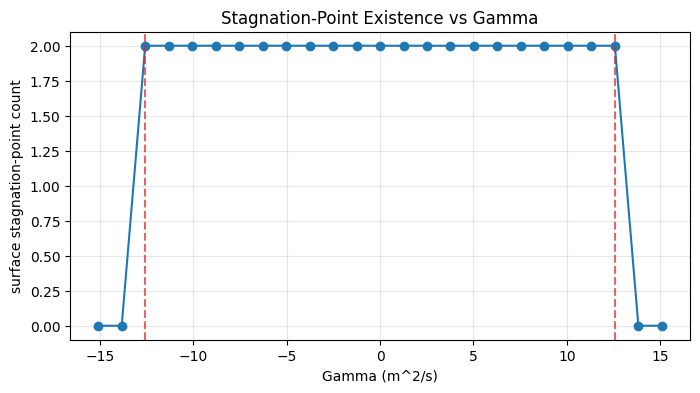

saved: /Users/fancy2/work/code/fubianhanshu/flow_project2/reports/figures/stage2_stagnation_scan.png


In [5]:
gammas = np.linspace(-4*np.pi*U*a*1.2, 4*np.pi*U*a*1.2, 25)
count_list = []
for g in gammas:
    sim_g = FlowSimulator(U=U, a=a, gamma=float(g), n=151)
    sp = sim_g.run()['stagnation']
    count_list.append(sp.size)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gammas, count_list, marker='o', linewidth=1.5)
ax.axvline(-4*np.pi*U*a, linestyle='--', color='tab:red', alpha=0.7)
ax.axvline(4*np.pi*U*a, linestyle='--', color='tab:red', alpha=0.7)
ax.set_xlabel('Gamma (m^2/s)')
ax.set_ylabel('surface stagnation-point count')
ax.set_title('Stagnation-Point Existence vs Gamma')
ax.grid(alpha=0.3)

stag_fig_path = fig_dir / 'stage2_stagnation_scan.png'
fig.savefig(stag_fig_path, dpi=180, bbox_inches='tight')

plt.show()
print('saved:', stag_fig_path)